# 06c — Shared Reid + de Pablo low-T + noisy-LJ propagator with frozen AE

In [9]:
%matplotlib inline
import os, sys
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT/'src'))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lss.data import load_dataset, tag_simulation_source
from lss.latent.experiment import run_latent_experiment, seed_everything
from lss.latent.experiment import evaluate_rollout_horizons
from lss.latent.simulation import r2_score
from lss.latent.training import encode_reference_context, encode_transition_batch
from lss.plotting import PAPER_COLORS, apply_editorial_style, dataset_color, style_axes
from lss.utils import resolve_device
apply_editorial_style()
DEVICE = resolve_device('auto')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
SEED = 3456456
TRAIN_PER_SOURCE = 20
VAL_PER_SOURCE = 20
TRAIN_FRAMES = 101
OUTPUT = PROJECT_ROOT/'notebooks'/'results'/'06c_reid_propagator_screen'
AE_CACHE = OUTPUT/'ae_06b_v7_ceiling_seed3456456_train20_val20.pt'
MODEL_KEY = 'reid_depablo_low_temp_lj_noisy_equal_loss_static_delta_v1'
PROP_CACHE = OUTPUT/f'{MODEL_KEY}.pt'
assert AE_CACHE.is_file(), AE_CACHE
DATASETS = {
    'reid': {'label': 'Reid', 'path': PROJECT_ROOT/'data'/'reid_200_frames.pt'},
    'depablo_low_temp': {'label': 'de Pablo low-T', 'path': PROJECT_ROOT/'data'/'depablo-near-zero-temp.pt'},
    'lj_noisy': {'label': 'noisy LJ', 'path': PROJECT_ROOT/'data'/'lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt'},
}
for spec in DATASETS.values():
    assert spec['path'].is_file(), spec['path']
MIXTURE = [
    {'name': key, 'label': spec['label'], 'path': str(spec['path']),
     'train_count': TRAIN_PER_SOURCE, 'val_count': VAL_PER_SOURCE, 'edge_vector_dim': 2}
    for key, spec in DATASETS.items()
]
source = {
    'dataset_name': 'mixed_sources_shared', 'source_name': 'reid-depablo-low-temp-lj-noisy mixture',
    'label': 'shared AE, Reid + de Pablo low-T + noisy-LJ propagator', 'path': MIXTURE[0]['path'],
    'dataset_mixture': MIXTURE,
}
print({'frozen_ae': str(AE_CACHE), 'seed': SEED, 'train_per_source': TRAIN_PER_SOURCE,
       'val_per_source': VAL_PER_SOURCE, 'propagator_training_sources': list(DATASETS)})

{'frozen_ae': '/home/alexz/Documents/course_project/notebooks/results/06c_reid_propagator_screen/ae_06b_v7_ceiling_seed3456456_train20_val20.pt', 'seed': 3456456, 'train_per_source': 20, 'val_per_source': 20, 'propagator_training_sources': ['reid', 'depablo_low_temp']}


In [ ]:
prop_config = {
    'dataset_name': 'mixed_sources_shared', 'split_seed': SEED, 'model_seed': SEED,
    'device': str(DEVICE), 'pos_dim': 2, 'batch_graphs': 32, 'frame_skip': 1,
    'coordinate_normalization': 'position_normalization', 'train_frame_start_order': 0,
    'edge_mode': 'compact_stored', 'static_context_use_physical_reference': True,
    'ae_config': {
        'latent_dim': 2, 'latent_tokens': 32, 'hidden_size': 96, 'model': 'attention',
        'edge_feature_dim': 4, 'target_mode': 'normalized_delta', 'node_feature_mode': 'normalized_delta',
        'max_train_frames_per_sim': TRAIN_FRAMES, 'val_frame_skip': 1, 'max_val_frames_per_sim': TRAIN_FRAMES,
        'max_epochs': 30, 'patience': 6, 'lr': 1e-4, 'weight_decay': 1e-5,
        'balance_sources': False, 'mix_sources': True,
    },
    'propagator_config': {
        'max_train_transitions_per_sim': TRAIN_FRAMES - 1, 'max_epochs': 30, 'patience': 6,
        'lr': 1e-4, 'weight_decay': 1e-5, 'hidden_size': 64,
        'objective': 'one_step', 'model': 'delta_mlp', 'loss': 'delta', 'step_stride': 1,
        'mix_sources': True, 'balance_sources': False,
        'train_trajectories_per_source': {key: TRAIN_PER_SOURCE for key in DATASETS},
        'val_trajectories_per_source': {key: VAL_PER_SOURCE for key in DATASETS},
        'source_loss_reduction': 'equal',
        'use_static_context': True, 'context_pool': 'mean', 'context_dim': 16,
        'context_include_source_id': False, 'rollout_eval_every_epoch': True,
        'rollout_eval_interval': 1, 'rollout_eval_horizons': [100],
        'rollout_eval_sims_per_source': VAL_PER_SOURCE,
    },
    'pretrained_ae_cache_path': str(AE_CACHE),
    'pretrained_ae_config_keys': [
        'split_seed', 'coordinate_normalization', 'edge_mode', 'pos_dim', 'latent_dim',
        'latent_tokens', 'hidden_size', 'autoencoder_model', 'edge_feature_dim',
        'node_feature_mode', 'ae_target_mode', 'ae_max_train_frames_per_sim',
        'ae_max_val_frames_per_sim',
    ],
    'pretrained_ae_skip_stat_fitting': True,
    'pretrained_ae_require_matching_normalizers': False,
    'should_rollout': True, 'should_train_propagator': True,
    'force_train': not PROP_CACHE.exists(), 'force_train_autoencoder': False,
    'cache_path': str(PROP_CACHE), 'cache_require_matching_config': True,
    'dataset_mixture': MIXTURE, 'early_stop_min_delta': 1e-5,
    'rollout_steps_grid': [5, 10, 25, 50, 75, 100],
    'rollout_eval_splits': ['val', 'test'],
    'rollout_final_eval_sims_per_source': 30,
}
seed_everything(SEED)
result = run_latent_experiment(source, prop_config, device=DEVICE)
display(result['split_info'])


=== shared AE, Reid + de Pablo low-T propagator ===
          source                                                                path  total  train  reserved_train_pool  val  test
            reid        /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     20                   20   20    62
depablo_low_temp /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200     20                   20   20   160
source-mixed AE coverage: {'reid': {'trajectories': 20, 'frames': 2020}, 'depablo_low_temp': {'trajectories': 20, 'frames': 2020}}
autoencoder
loaded pretrained AE: /home/alexz/Documents/course_project/notebooks/results/06c_reid_propagator_screen/ae_06b_v7_ceiling_seed3456456_train20_val20.pt
propagator training coverage: {'reid': {'trajectories': 20, 'transitions': 2000}, 'depablo_low_temp': {'trajectories': 20, 'transitions': 2000}}
latent propagator: objective=one_step step_stride=1 horizons=None train_rows=4000 val_rows=4000
propagator 0001 tra

,source,path,total,train,reserved_train_pool,val,test
0,reid,/home/alexz/Documents/course_project/data/reid...,102,20,20,20,62
1,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,20,20,20,160


In [4]:
# The shared source-wise diagnostics follow after training.

In [5]:
shared_result = result
source_r2_columns = ['epoch', *[f'val_rollout_source_{key}_p_ratio_r2' for key in DATASETS]]
display(shared_result['split_info'])
display(shared_result['dyn_history'].reindex(columns=source_r2_columns).dropna(how='all').round(3))

,source,path,total,train,reserved_train_pool,val,test
0,reid,/home/alexz/Documents/course_project/data/reid...,102,20,20,20,62
1,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,20,20,20,160


,epoch,val_rollout_source_reid_p_ratio_r2,val_rollout_source_depablo_low_temp_p_ratio_r2
0,1,-0.137,0.210
1,2,0.410,0.903
2,3,0.542,0.891
3,4,0.613,0.899
4,5,0.667,0.912
5,6,0.671,0.919
6,7,0.603,0.909
7,8,0.646,0.918
8,9,0.626,0.940
9,10,0.578,0.928


,split,source,n,rollout_p_ratio_r2
0,val,Reid,20,0.671
1,val,de Pablo low-T,20,0.919
2,test,Reid,30,0.708
3,test,de Pablo low-T,30,0.942


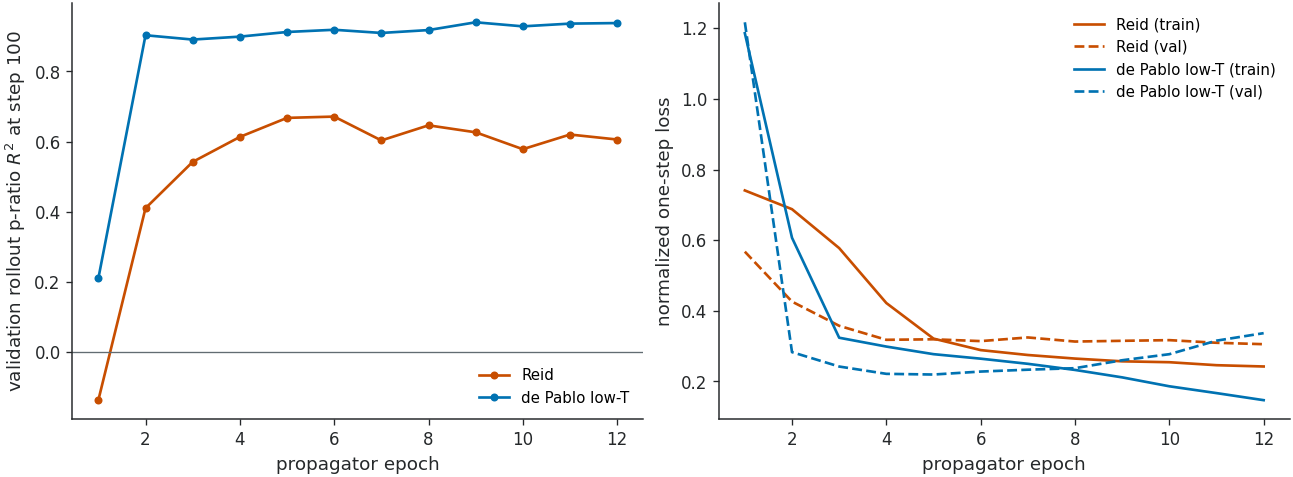

In [6]:
shared_rows = shared_result['rollout_rows'].query("rollout_steps == 100").copy()
shared_summary = []
for split in ('val', 'test'):
    for source_key, spec in DATASETS.items():
        subset = shared_rows.loc[(shared_rows.split == split) & (shared_rows.source == source_key)]
        shared_summary.append({'split': split, 'source': spec['label'], 'n': len(subset),
                               'rollout_p_ratio_r2': r2_score(subset.true_p_ratio, subset.pred_p_ratio) if len(subset) > 1 else np.nan})
display(pd.DataFrame(shared_summary).round(3))
history = shared_result['dyn_history']
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.0), constrained_layout=True)
for source_key, spec in DATASETS.items():
    r2_column = f'val_rollout_source_{source_key}_p_ratio_r2'
    r2_rows = history[['epoch', r2_column]].dropna() if r2_column in history else pd.DataFrame()
    if not r2_rows.empty:
        axes[0].plot(r2_rows.epoch, r2_rows[r2_column], marker='o', markersize=3.8, linewidth=1.6, color=dataset_color(source_key), label=spec['label'])
    color = dataset_color(source_key)
    for split, linestyle in [('train', '-'), ('val', '--')]:
        loss_column = f'{split}_source_{source_key}_loss_norm'
        loss_rows = history[['epoch', loss_column]].dropna() if loss_column in history else pd.DataFrame()
        if not loss_rows.empty:
            axes[1].plot(loss_rows.epoch, loss_rows[loss_column], linestyle=linestyle, linewidth=1.6, color=color, label=f'{spec["label"]} ({split})')
axes[0].axhline(0, color=PAPER_COLORS['slate'], lw=.8)
style_axes(axes[0], xlabel='propagator epoch', ylabel='validation rollout p-ratio $R^2$ at step 100', legend=True)
style_axes(axes[1], xlabel='propagator epoch', ylabel='normalized one-step loss', legend=True)
plt.show()

In [7]:
GRADIENT_BATCH_SIZE = 32
def gradient_batch_rows(source_key):
    candidates = [
        (sim_idx, step, step + 1)
        for sim_idx, simulation in enumerate(shared_result['train_data'])
        if getattr(simulation[0], 'source_name', None) == source_key
        for step in range(TRAIN_FRAMES - 1)
    ]
    generator = torch.Generator().manual_seed(SEED + sum(map(ord, source_key)))
    chosen = torch.randperm(len(candidates), generator=generator)[:GRADIENT_BATCH_SIZE].tolist()
    return [candidates[index] for index in chosen]

def source_gradient(source_key):
    dyn, ae = shared_result['dyn'], shared_result['ae']
    stats, normalizers = shared_result['latent_stats'], shared_result['normalizers']
    sims, rows = shared_result['train_data'], gradient_batch_rows(source_key)
    was_training = dyn.training
    dyn.eval()
    z0, z1 = encode_transition_batch(ae, sims, rows, pos_dim=2, node_feature_mode='normalized_delta', normalizers=normalizers, device=DEVICE)
    contexts = torch.stack([encode_reference_context(ae, sims[int(row[0])], pos_dim=2, normalizers=normalizers, device=DEVICE, pool_mode='mean') for row in rows])
    prediction = dyn(stats.normalize_z(z0), stats.normalize_context(contexts))
    loss = (prediction - stats.normalize_dz(z1 - z0)).square().mean()
    parameters = [parameter for parameter in dyn.parameters() if parameter.requires_grad]
    gradients = torch.autograd.grad(loss, parameters, allow_unused=True)
    vector = torch.cat([gradient.reshape(-1) for gradient in gradients if gradient is not None]).detach()
    dyn.train(was_training)
    return float(loss.detach()), vector

gradient_losses, gradient_vectors = {}, {}
for source_key in DATASETS:
    gradient_losses[source_key], gradient_vectors[source_key] = source_gradient(source_key)
gradient_cosine = pd.DataFrame(index=DATASETS, columns=DATASETS, dtype=float)
for left, left_gradient in gradient_vectors.items():
    for right, right_gradient in gradient_vectors.items():
        gradient_cosine.loc[left, right] = (torch.dot(left_gradient, right_gradient) / (left_gradient.norm() * right_gradient.norm()).clamp_min(1e-12)).item()
display(pd.DataFrame({'source': list(gradient_losses), 'one_step_delta_loss': list(gradient_losses.values())}).round(5))
display(gradient_cosine.round(3))

,source,one_step_delta_loss
0,reid,0.27472
1,depablo_low_temp,0.19093


,reid,depablo_low_temp
reid,1.000,0.138
depablo_low_temp,0.138,1.000


,split,source,n,rollout_p_ratio_r2
0,unseen propagator,de Pablo mixed-T,30,0.891


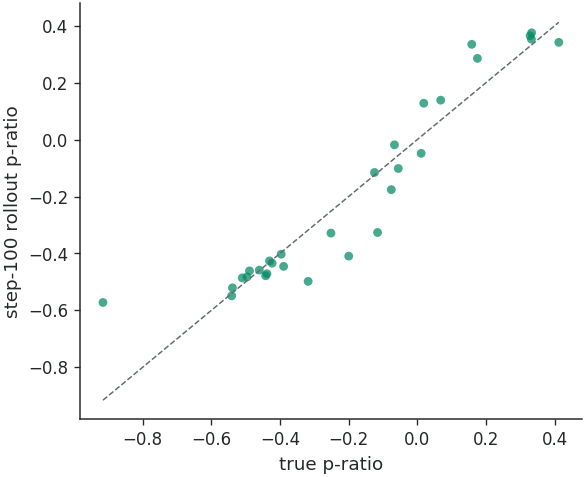

In [10]:
MIXED_TEMP_PATH = PROJECT_ROOT/'data'/'depablo-10k-mix-temp.pt'
MIXED_TEMP_EVAL_SIMS = 30
mixed_temp_sims = load_dataset(MIXED_TEMP_PATH, edge_vector_dim=2, coordinate_normalization='position_normalization', pos_dim=2)
mixed_order = torch.randperm(len(mixed_temp_sims), generator=torch.Generator().manual_seed(SEED)).tolist()
mixed_temp_sims = [tag_simulation_source(mixed_temp_sims[index], 'depablo_mixed_temp') for index in mixed_order[:MIXED_TEMP_EVAL_SIMS]]
mixed_rows, mixed_stats = evaluate_rollout_horizons(shared_result['ae'], shared_result['dyn'], mixed_temp_sims, shared_result['latent_stats'], cfg=shared_result['params'], normalizers=shared_result['normalizers'], dataset='unseen de Pablo mixed-T', split_name='unseen', rollout_steps=[100], device=DEVICE)
mixed_100 = mixed_rows.query('rollout_steps == 100').copy()
mixed_r2 = r2_score(mixed_100.true_p_ratio, mixed_100.pred_p_ratio) if len(mixed_100) > 1 else np.nan
display(pd.DataFrame([{'split': 'unseen propagator', 'source': 'de Pablo mixed-T', 'n': len(mixed_100), 'rollout_p_ratio_r2': mixed_r2}]).round(3))
fig, ax = plt.subplots(figsize=(4.9, 4.0), constrained_layout=True)
if len(mixed_100):
    ax.scatter(mixed_100.true_p_ratio, mixed_100.pred_p_ratio, s=28, alpha=.72, color=dataset_color('depablo_mixed_temp'), edgecolor='none')
    limits = np.r_[mixed_100.true_p_ratio, mixed_100.pred_p_ratio]
    lo, hi = np.nanmin(limits), np.nanmax(limits)
    ax.plot([lo, hi], [lo, hi], '--', color=PAPER_COLORS['slate'], lw=.9)
style_axes(ax, xlabel='true p-ratio', ylabel='step-100 rollout p-ratio', legend=False)
plt.show()